In [63]:
import pandas as pd

cleaned_df = pd.read_csv("cleaned_data.csv")
print(cleaned_df.head())
cleaned_df["Primary Type"]=cleaned_df["Primary Type"].astype("category")
cleaned_df["Domestic"]=cleaned_df["Domestic"].astype(int)
print(cleaned_df.head())

                 Primary Type                    Location Description  Arrest  \
0  OFFENSE INVOLVING CHILDREN                               residence       1   
1                   NARCOTICS                                sidewalk       1   
2             CRIMINAL DAMAGE  parking lot / garage (non residential)       0   
3                       THEFT  parking lot / garage (non residential)       0   
4                 SEX OFFENSE                               residence       0   

   Domestic  Year  
0     False  2022  
1     False  2023  
2     False  2023  
3     False  2023  
4     False  2021  
                 Primary Type                    Location Description  Arrest  \
0  OFFENSE INVOLVING CHILDREN                               residence       1   
1                   NARCOTICS                                sidewalk       1   
2             CRIMINAL DAMAGE  parking lot / garage (non residential)       0   
3                       THEFT  parking lot / garage (non residential)

In [64]:
print(cleaned_df.shape)

(90344, 5)


In [65]:
print(cleaned_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90344 entries, 0 to 90343
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Primary Type          90344 non-null  category
 1   Location Description  90344 non-null  object  
 2   Arrest                90344 non-null  int64   
 3   Domestic              90344 non-null  int64   
 4   Year                  90344 non-null  int64   
dtypes: category(1), int64(3), object(1)
memory usage: 2.8+ MB
None


In [66]:
X=cleaned_df.drop(columns=["Arrest"])
y=cleaned_df["Arrest"]
print("X features:")
print(X)
print("y target:")
print(y)

X features:
                     Primary Type                    Location Description  \
0      OFFENSE INVOLVING CHILDREN                               residence   
1                       NARCOTICS                                sidewalk   
2                 CRIMINAL DAMAGE  parking lot / garage (non residential)   
3                           THEFT  parking lot / garage (non residential)   
4                     SEX OFFENSE                               residence   
...                           ...                                     ...   
90339  OFFENSE INVOLVING CHILDREN                               residence   
90340          DECEPTIVE PRACTICE                               apartment   
90341          DECEPTIVE PRACTICE                               residence   
90342                    HOMICIDE                                   porch   
90343                       THEFT                               residence   

       Domestic  Year  
0             0  2022  
1             0

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression

cleaned_df = cleaned_df.rename(columns={"Arrest": "y_reg"})

X = cleaned_df.drop("y_reg", axis=1)  
y = cleaned_df["y_reg"]  

print(X)
print(y)

                     Primary Type                    Location Description  \
0      OFFENSE INVOLVING CHILDREN                               residence   
1                       NARCOTICS                                sidewalk   
2                 CRIMINAL DAMAGE  parking lot / garage (non residential)   
3                           THEFT  parking lot / garage (non residential)   
4                     SEX OFFENSE                               residence   
...                           ...                                     ...   
90339  OFFENSE INVOLVING CHILDREN                               residence   
90340          DECEPTIVE PRACTICE                               apartment   
90341          DECEPTIVE PRACTICE                               residence   
90342                    HOMICIDE                                   porch   
90343                       THEFT                               residence   

       Domestic  Year  
0             0  2022  
1             0  2023  
2  

In [68]:
cleaned_df["y_clf"] = cleaned_df["Domestic"]
print(cleaned_df["y_clf"].value_counts())

y_clf
0    75477
1    14867
Name: count, dtype: int64


In [69]:
categorical_cols = ["Primary Type", "Location Description"]

cleaned_df_encoded = pd.get_dummies(cleaned_df, columns=categorical_cols, drop_first=True)
print(cleaned_df_encoded.head())

   y_reg  Domestic  Year  y_clf  Primary Type_ASSAULT  Primary Type_BATTERY  \
0      1         0  2022      0                 False                 False   
1      1         0  2023      0                 False                 False   
2      0         0  2023      0                 False                 False   
3      0         0  2023      0                 False                 False   
4      0         0  2021      0                 False                 False   

   Primary Type_BURGLARY  Primary Type_CONCEALED CARRY LICENSE VIOLATION  \
0                  False                                           False   
1                  False                                           False   
2                  False                                           False   
3                  False                                           False   
4                  False                                           False   

   Primary Type_CRIMINAL DAMAGE  Primary Type_CRIMINAL SEXUAL ASSAUL

In [70]:
X = cleaned_df_encoded.drop(["y_reg", "y_clf"], axis=1)
y_reg = cleaned_df_encoded["y_reg"]
y_clf = cleaned_df_encoded["y_clf"]

print(X)
print(y_reg)
print(y_clf)

       Domestic  Year  Primary Type_ASSAULT  Primary Type_BATTERY  \
0             0  2022                 False                 False   
1             0  2023                 False                 False   
2             0  2023                 False                 False   
3             0  2023                 False                 False   
4             0  2021                 False                 False   
...         ...   ...                   ...                   ...   
90339         1  2022                 False                 False   
90340         0  2025                 False                 False   
90341         0  2024                 False                 False   
90342         0  2025                 False                 False   
90343         0  2025                 False                 False   

       Primary Type_BURGLARY  Primary Type_CONCEALED CARRY LICENSE VIOLATION  \
0                      False                                           False   
1          

In [71]:

from sklearn.preprocessing import StandardScaler


X_reg_train,X_reg_test,y_reg_train,y_reg_test=train_test_split(X,y_reg,test_size=0.20,random_state=42)
X_clf_train,X_clf_test,y_clf_train,y_clf_test=train_test_split(X,y_clf,test_size=0.20,random_state=42)

scaler=StandardScaler()
X_reg_train_scaled=scaler.fit_transform(X_reg_train)
X_reg_test_scaled=scaler.transform(X_reg_test)

X_clf_train_scaled=scaler.fit_transform(X_clf_train)
X_clf_test_scaled=scaler.transform(X_clf_test)

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

reg_model = LinearRegression()
reg_model.fit(X_reg_train_scaled, y_reg_train)

y_reg_pred = reg_model.predict(X_reg_test_scaled)

mse = mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print("Regression MSE:",round(mse,2))
print("Regression R²:", round(r2,2))

Regression MSE: 0.08
Regression R²: 0.3


In [73]:
import numpy as np

feature_names = X_reg_train.columns

coefficients = reg_model.coef_
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
})



top3 = coef_df.sort_values(by="AbsCoefficient", ascending=False).head(3)
print("\nTop 3 features with largest absolute coefficients:")
print(top3)

Domestic: 0.0166
Year: 0.0023
Primary Type_ASSAULT: -0.0326
Primary Type_BATTERY: -0.0195
Primary Type_BURGLARY: -0.0212
Primary Type_CONCEALED CARRY LICENSE VIOLATION: 0.0173
Primary Type_CRIMINAL DAMAGE: -0.0553
Primary Type_CRIMINAL SEXUAL ASSAULT: -0.0096
Primary Type_CRIMINAL TRESPASS: 0.0055
Primary Type_DECEPTIVE PRACTICE: -0.0470
Primary Type_GAMBLING: 0.0071
Primary Type_HOMICIDE: 0.0226
Primary Type_HUMAN TRAFFICKING: 0.0012
Primary Type_INTERFERENCE WITH PUBLIC OFFICER: 0.0268
Primary Type_INTIMIDATION: -0.0045
Primary Type_KIDNAPPING: -0.0036
Primary Type_LIQUOR LAW VIOLATION: 0.0185
Primary Type_MOTOR VEHICLE THEFT: -0.0537
Primary Type_NARCOTICS: 0.1228
Primary Type_NON-CRIMINAL: -0.0012
Primary Type_OBSCENITY: 0.0016
Primary Type_OFFENSE INVOLVING CHILDREN: -0.0067
Primary Type_OTHER NARCOTIC VIOLATION: -0.0000
Primary Type_OTHER OFFENSE: -0.0123
Primary Type_PROSTITUTION: 0.0117
Primary Type_PUBLIC INDECENCY: 0.0025
Primary Type_PUBLIC PEACE VIOLATION: 0.0132
Primary Ty

In [52]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_reg_train_scaled, y_reg_train)

y_ridge_pred = ridge_model.predict(X_reg_test_scaled)

mse_ridge = mean_squared_error(y_reg_test,y_ridge_pred)
r2_ridge = r2_score(y_reg_test, y_ridge_pred)

print("Ridge Regression MSE:", round(mse_ridge,2))
print("Ridge Regression R²:", round(r2_ridge,2))

Ridge Regression MSE: 0.08
Ridge Regression R²: 0.3


Class distribution in training set:
y_clf
0    0.835393
1    0.164607
Name: proportion, dtype: float64
Applying SMOTE to balance classes...
Confusion Matrix:
 [[15099     0]
 [    0  2970]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15099
           1       1.00      1.00      1.00      2970

    accuracy                           1.00     18069
   macro avg       1.00      1.00      1.00     18069
weighted avg       1.00      1.00      1.00     18069



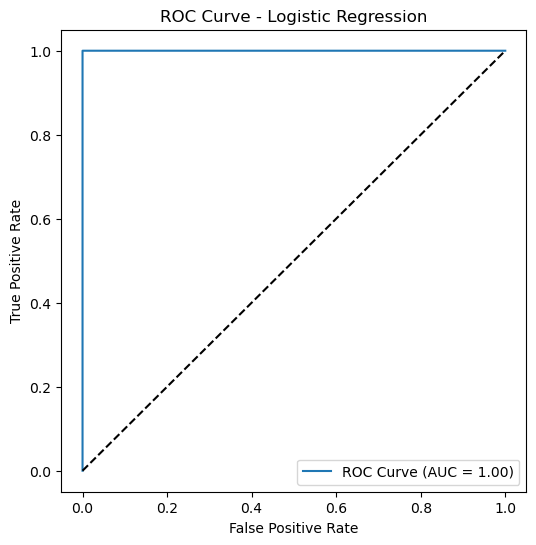

Chosen imbalance strategy: SMOTE (oversampling)
AUC: 1.0


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE

print("Class distribution in training set:")
print(y_clf_train.value_counts(normalize=True))

if y_clf_train.value_counts(normalize=True).min() < 0.35:
    print("Applying SMOTE to balance classes...")
    smote = SMOTE(random_state=42)
    X_clf_train_resampled, y_clf_train_resampled = smote.fit_resample(X_clf_train_scaled, y_clf_train)
    chosen_strategy = "SMOTE (oversampling)"
else:
    print("Using class_weight='balanced' in Logistic Regression...")
    X_clf_train_resampled, y_clf_train_resampled = X_clf_train_scaled, y_clf_train
    chosen_strategy = "class_weight='balanced'"

clf_model = LogisticRegression(max_iter=1000, class_weight='balanced' if chosen_strategy=="class_weight='balanced'" else None)
clf_model.fit(X_clf_train_resampled, y_clf_train_resampled)   


y_clf_pred = clf_model.predict(X_clf_test_scaled)
y_pred_proba = clf_model.predict_proba(X_clf_test_scaled)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_clf_test, y_clf_pred))
print("Classification Report:\n", classification_report(y_clf_test, y_clf_pred))

fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_proba)
auc = roc_auc_score(y_clf_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

print("Chosen imbalance strategy:", chosen_strategy)
print("AUC:", auc)


In [75]:
from sklearn.metrics import precision_score, recall_score, f1_score


y_pred_proba = clf_model.predict_proba(X_clf_test_scaled)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for thresh in thresholds:
    
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
   
    precision = precision_score(y_clf_test, y_pred_thresh)
    recall = recall_score(y_clf_test, y_pred_thresh)
    f1 = f1_score(y_clf_test, y_pred_thresh)
    results.append([thresh, precision, recall, f1])
    
print("Threshold | Precision | Recall | F1")
for row in results:
    print(f"{row[0]:.2f}      | {row[1]:.3f}     | {row[2]:.3f}   | {row[3]:.3f}")


Threshold | Precision | Recall | F1
0.30      | 1.000     | 1.000   | 1.000
0.40      | 1.000     | 1.000   | 1.000
0.50      | 1.000     | 1.000   | 1.000
0.60      | 1.000     | 1.000   | 1.000
0.70      | 1.000     | 1.000   | 1.000


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score


baseline_clf = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
baseline_clf.fit(X_clf_train_resampled, y_clf_train_resampled)

y_pred_baseline = baseline_clf.predict(X_clf_test_scaled)
y_proba_baseline = baseline_clf.predict_proba(X_clf_test_scaled)[:,1]

precision_baseline = precision_score(y_clf_test, y_pred_baseline)
recall_baseline = recall_score(y_clf_test,y_pred_baseline)
auc_baseline = roc_auc_score(y_clf_test,y_proba_baseline)


ridge_clf = LogisticRegression(max_iter=1000, C=0.01, class_weight='balanced')
ridge_clf.fit(X_clf_train_resampled, y_clf_train_resampled)

y_pred_ridge = ridge_clf.predict(X_clf_test_scaled)
y_proba_ridge = ridge_clf.predict_proba(X_clf_test_scaled)[:,1]

precision_ridge = precision_score(y_clf_test, y_pred_ridge)
recall_ridge = recall_score(y_clf_test,y_pred_ridge)
auc_ridge = roc_auc_score(y_clf_test, y_proba_ridge)


print("Model                | Precision | Recall | AUC")
print(f"Baseline (C=1.0)     | {precision_baseline:.3f}     | {recall_baseline:.3f}   | {auc_baseline:.3f}")
print(f"Regularized (C=0.01) | {precision_ridge:.3f}     | {recall_ridge:.3f}   | {auc_ridge:.3f}")

Model                | Precision | Recall | AUC
Baseline (C=1.0)     | 1.000     | 1.000   | 1.000
Regularized (C=0.01) | 1.000     | 1.000   | 1.000


In [77]:
import numpy as np
from sklearn.metrics import roc_auc_score


y_proba_baseline = baseline_clf.predict_proba(X_clf_test_scaled)[:,1]
y_proba_ridge = ridge_clf.predict_proba(X_clf_test_scaled)[:,1]

n_bootstrap = 500
auc_diffs = []


for i in range(n_bootstrap):
    
    sample_idx = np.random.choice(len(y_clf_test), size=len(y_clf_test), replace=True)
    
 
    y_true_sample = y_clf_test.iloc[sample_idx]
    y_proba_base_sample = y_proba_baseline[sample_idx]
    y_proba_ridge_sample = y_proba_ridge[sample_idx]
    
    
    auc_base = roc_auc_score(y_true_sample, y_proba_base_sample)
    auc_ridge = roc_auc_score(y_true_sample, y_proba_ridge_sample)
    
 
    auc_diffs.append(auc_base - auc_ridge)


auc_diffs = np.array(auc_diffs)


mean_diff = np.mean(auc_diffs)
ci_lower = np.percentile(auc_diffs, 2.5)
ci_upper = np.percentile(auc_diffs, 97.5)

print("Mean AUC difference (C=1.0 - C=0.01):",mean_diff)
print("95% CI for difference:", (ci_lower, ci_upper))

Mean AUC difference (C=1.0 - C=0.01): -1.9984014443252816e-18
95% CI for difference: (np.float64(-1.1102230246251565e-16), np.float64(1.1102230246251565e-16))
